# Charlie's fantastic SQUID data plotter
Imports .dat files straight from MPMS3 SQUID and plots MvT and MvH curves.
Extracts stats of the MvT plot. Detects the Morin transition temperature, it's width (a FWHM approach).
Grabs Temperature at which the MvH data was taken.
It performs diamagnetic signal subtraction from the MvH curves - fits the high and low field data to y=m*x + c and subtracts this to leave only the weak ferromagnetism arrising from the alpha-Fe2O3 layer.

## IP Anisotropy analysis
Plots the width and height of the MvH hysteresis loops as a function of sample rotation angle and temperature. You will have to manually tell the code what angle you took the data.



In [8]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import os
from scipy.optimize import curve_fit
import scipy.ndimage
import scipy.signal as ss
from scipy.signal import savgol_filter
from scipy.signal import find_peaks
from numpy import logical_and as _and
from numpy import logical_or as _or
import matplotlib.cm as cm

In [9]:
folder = "./SURF1560_Thick_2degMC_0degMount/"
file = "MT 500 Oe-redo.dat"
data = os.path.join(folder, file)
df = pd.read_csv(data, skiprows = 44, header = 0)

In [10]:
df.head(5)

,Comment,Time Stamp (sec),Temperature (K),Magnetic Field (Oe),Moment (emu),M. Std. Err. (emu),Transport Action,Averaging Time (sec),Frequency (Hz),Peak Amplitude (mm),...,Map 07,Map 08,Map 09,Map 10,Map 11,Map 12,Map 13,Map 14,Map 15,Map 16
0,NaN,3.910311e+09,200.150192,500.417328,-0.000009,1.058366e-08,1,4,13.901246,5.007193,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,NaN,3.910311e+09,200.143982,500.417328,-0.000009,9.746513e-09,1,4,13.901246,5.007054,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,NaN,3.910311e+09,200.134468,500.417328,-0.000009,8.746701e-09,1,4,13.901246,5.007046,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,NaN,3.910311e+09,200.127441,500.417328,-0.000009,1.179456e-08,1,4,13.901246,5.006933,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,NaN,3.910311e+09,200.119560,500.417328,-0.000009,9.636433e-09,1,4,13.901246,5.006853,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [11]:
def plot_df(df, x, y, title, l='', save=False):
    '''Plots data from a dataframe df with column labels x and y'''
    plt.scatter(df[x], df[y], label=l)
    plt.title(title)
    plt.xlabel(x)
    plt.ylabel(y)
    plt.legend()
    if (save==True):
        plt.savefig(title)
    

def plot_MT(folder, file, sample):
    '''Use this function to plot MT loops'''
    data = os.path.join(folder, file)
    df = pd.read_csv(data, skiprows = 44, header = 0)
    x = 'Temperature (K)'
    y = 'Moment (emu)'
    title = 'MvT' + ' ' + sample
    print(sample, np.max(df[y]) - np.min(df[y]))
    plot_df(df,x,y,title)
    plt.show()

def linear_func(x, m, c):
    return m*x + c



    

In [120]:
plt.rcParams.update({'font.size': 18})
plt.rcParams.update({'ytick.right': True})
plt.rcParams.update({'xtick.top': True})
plt.rcParams.update({'ytick.direction': 'in'})
plt.rcParams.update({'xtick.direction': 'in'})
plt.rcParams['font.family'] = 'serif'
annotate_font_size = 15

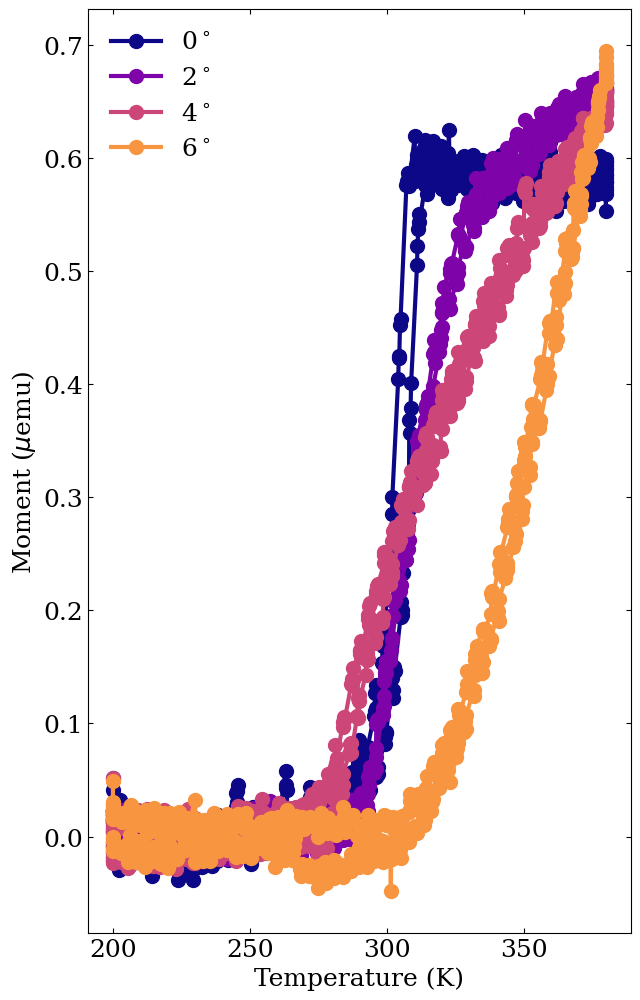

In [131]:
folder1 = "./SURF1560_Thick_0degMC_0degMount"
file = "MT 500 Oe.dat"
sample = 'SURF1560_Thick_0degMC_0degMount'
#plot_MT(folder1, file, sample)

folder2 = "./SURF1560_Thick_2degMC_0degMount"
file = "MT 500 Oe-redo.dat"
sample = 'SURF1560_Thick_2degMC_0degMount'
#plot_MT(folder2, file, sample)

folder3 = "./SURF1560_Thick_4degMC_0degMount"
file = "MT 500 Oe.dat"
sample = 'SURF1560_Thick_4degMC_0degMount'
#plot_MT(folder3, file, sample)

folder4 = "./SURF1560_Thick_6degMC_0degMount"
file = "MT 500 Oe.dat"
sample = 'SURF1560_Thick_6degMC_0degMount'
#plot_MT(folder4, file, sample)

folder5 = "./SURF1560_Thick_2degMC_45CWdegMount_v2"
file = "MT 500 Oe.dat"
sample = 'SURF1560_Thick_2degMC_45CWdegMount_v2'


MT_folders = [folder1, folder2, folder3, folder4, folder5]

x = 'Temperature (K)'
y = 'Moment (emu)'

fig, axes = plt.subplots(1, 1, figsize=(7, 12))

num_lines =5
colors = cm.plasma(np.linspace(0, 1, num_lines))  # Use the 'viridis' 

files = ["MT 500 Oe.dat", "MT 500 Oe-redo.dat", "MT 500 Oe.dat", "MT 500 Oe.dat", "MT 500 Oe.dat"]
#labels = ['0$^\circ$MC','2$^\circ$MC','4$^\circ$MC','6$^\circ$MC', '2$^\circ$MC 45$^\circ$ mount']
labels = [r'0$^\circ$',r'2$^\circ$',r'4$^\circ$',r'6$^\circ$', r'2$^\circ$MC', r'45$^\circ$ mount']
for i in [0,1,2,3]:#,4]:
    data = os.path.join(MT_folders[i], files[i])
    df = pd.read_csv(data, skiprows = 44, header = 0)
    x_dat = np.array(df[x])
    y_dat = np.array(df[y])
    indicies = np.where(_and(x_dat>205, x_dat<250))
    #print(indicies)
    y_dat = y_dat - np.mean(y_dat[indicies]) #Subtract the offset
    y_dat=y_dat*1e6
    #plt.scatter(x_dat, y_dat, label=labels[i], s=10)
    axes.plot(x_dat, y_dat, marker='o', c=colors[i], markersize=10, linewidth=3, label=labels[i])
    
#plt.xlim([275, 360])

#plt.title('MT data')
axes.legend(frameon=False)
axes.set_xlabel(x)
axes.set_ylabel(r'Moment ($\mu$emu)')
plt.savefig('MT_miscut_series_15.svg')
plt.show()


How many atoms are present in the hematite layer


In [122]:
muB = 9.3E-24 #JT^-1
moment = 0.6*1e-6*1e-3 #conversion factor
num_Fe = moment / (0.002*muB)
print(num_Fe)
num_unit_cells = (5e-3*5e-3*30e-9)/(5*5*13*1e-30)
print(num_unit_cells/1e16)

3.225806451612903e+16
0.23076923076923075


In [143]:
def plot_MH(folder, file1, sample,v, angle, low_lim=-5000, upper_lim=5000, filter=True, filter_len=30):
    '''Plots the DC moment MH loop'''
    data1 = os.path.join(folder, file1)
    df1 = pd.read_csv(data1, skiprows = 44, header = 0)
    y = 'DC Moment Free Ctr (emu)' #'Moment (emu)'
    x = 'Magnetic Field (Oe)'
    fit_quality = 'DC Free Fit' #This is probably the R^2 value of the fit. Only include the data if >0.8
    Temperature1 = int(np.round(np.mean(df1['Temperature (K)'])))

    '''Number of data points to perform the fit over. Normal datasets are 300 points long but I exclude the first and final points from linear fit.'''

    data_y1 = np.array(df1[y])
    goodness = np.array(df1[fit_quality])
    good_data_index = np.where(_and(np.isnan(data_y1)==False,goodness>0.85))
    data_x = np.array(df1[x])

    xg = data_x[good_data_index]
    yg = data_y1[good_data_index]
    
    fitrange = np.where(_or(_and(xg<-10000, xg>-25000), _and(xg>10000, xg<25000)))
    print(yg[fitrange])
    popt1, pcov1 = curve_fit(linear_func, xg[fitrange], yg[fitrange])

    yg = yg - linear_func(xg, *popt1) #below T_M

    if (filter==True):
        yg = savgol_filter(yg, filter_len, 3)
        yg = savgol_filter(yg, filter_len, 3)
        

    '''Plotting section'''
    fig, ax = plt.subplots(ncols=1)
    
    title = 'MvH' + ' at '+ str(angle) + '$^\circ$'
    ax.set_title(title)

    ax.plot(xg, yg/v, label=str(Temperature1) + ' K')
    ax.scatter(xg, yg/v)
    ax.set_xlabel(x)
    ax.set_xlim([low_lim, upper_lim])
    ax.set_ylabel(y)
    ax.legend()
    fig.tight_layout()
    plt.show()
    #name = sample+ ' MvH' + ' '+ str(angle)
    #fig.savefig(name + '.png')
    return xg, yg

def plot_MH_difference(folder, file1, file2, sample,v, angle, low_lim=-5000, upper_lim=5000, filter=True, filter_len=30, flatten=True):
    '''Takes two MH data from the same sample at two different temperatures. Performs subtraction of diamagnetic substrate signal from each.
    Then it subtracts the two loops from each other, so that only the behaviour of the canted moment is visible.
    Then if flatten is set to True, subtract linear fit of the saturation to level off the saturation parts of the hysteresis loops'''
    colors = cm.plasma(np.linspace(0, 1, num_lines))
    
    data1 = os.path.join(folder, file1)
    df1 = pd.read_csv(data1, skiprows = 44, header = 0)

    data2 = os.path.join(folder, file2)
    df2 = pd.read_csv(data2, skiprows = 44, header = 0)
    
    y = 'Moment (emu)'
    x = 'Magnetic Field (Oe)'
    Temperature1 = int(np.round(np.mean(df1['Temperature (K)'])))
    Temperature2 = int(np.round(np.mean(df2['Temperature (K)'])))

    '''Number of data points to perform the fit over. Normal datasets are 300 points long but I exclude the first and final points from linear fit.'''
    data_y1 = np.array(df1[y])*1e6
    data_y2 = np.array(df2[y])*1e6
    good_data_index1 = np.where(np.isnan(data_y1)==False) #Needed if you ran a DC scan at the same time
    good_data_index2 = np.where(np.isnan(data_y2)==False)
    
    data_x = np.array(df1[x])
    data_x1 = np.array(df1[x])
    data_x2 = np.array(df2[x])

    data_y1 = data_y1[good_data_index1]
    data_y2 = data_y2[good_data_index2]

    data_x = data_x[good_data_index1]
    data_x1 = data_x#[good_data_index1]
    data_x2 = data_x2[good_data_index2]
    
    fitrange1 = np.where(_or(_and(data_x1<-15000, data_x1>-25000), _and(data_x1>15000, data_x1<25000)))
    fitrange2 = np.where(_or(_and(data_x2<-15000, data_x1>-25000), _and(data_x2>15000, data_x1<25000)))
    #popt1, pcov1 = curve_fit(linear_func, data_x1[fitrange], data_y1[fitrange])
    #popt2, pcov2 = curve_fit(linear_func, data_x2[fitrange], data_y2[fitrange])

    popt1, pcov1 = curve_fit(linear_func, data_x1[fitrange1], data_y1[fitrange1])
    popt2, pcov2 = curve_fit(linear_func, data_x2[fitrange2], data_y2[fitrange2])
    
    
    #print(popt1)
    #print(popt2)


    data_y1 = data_y1 - linear_func(data_x1, *popt1) #below T_M
    data_y2 = data_y2 - linear_func(data_x2, *popt2) # above T_M

    if (filter==True):
        #df[y] = ss.medfilt(df[y], 7)
        #df[x] = ss.medfilt(df[x], 7)
        data_y1 = savgol_filter(data_y1, filter_len, 3)
        data_x1 = savgol_filter(data_x1, filter_len, 3)
        data_y2 = savgol_filter(data_y2, filter_len, 3)
        data_x2 = savgol_filter(data_x2, filter_len, 3)
        

    '''Plotting section'''
    fig, ax = plt.subplots(ncols=2, figsize=(8, 4))
    
    title = 'MvH' + ' at '+ str(angle) + '$^\circ$'
    #ax[0].set_title(title)

    
    data_y = np.array(data_y1 - data_y2)

    height = 0 # If flattening didn't happen, we can't extract the loop height.
    
    if (flatten==True):
        '''Correct for the slight diamagnetic behaviour in the subtracted hysteresis loops.'''
        a, b, c, d = [-15000,-5000,5000,15000] #limits for the final linear adjustment fit
    
        index1 = np.where(_and(data_x > a, data_x < b))
        index2 = np.where(_and(data_x > c, data_x < d))
        popta, pcova = curve_fit(linear_func, data_x[index1], data_y[index1])
        poptb, pcovb = curve_fit(linear_func, data_x[index2], data_y[index2])
        m_av = (popta[0] + poptb[0]) /2
        c_av = (poptb[1] + popta[1]) /2
        height = -popta[1] + poptb[1]
        print('Gradients ', popta[0], poptb[0])
        data_y = data_y - linear_func(data_x, m_av, c_av)

    ax[1].plot(data_x, data_y, c=colors[2], linewidth=3)
    #ax[0].plot(data_x[fitrange], data_y[fitrange]) #Only plot data that was fitted to straight line
    ax[1].set_xlabel(x)
    ax[1].set_xlim([-5000,5000])
    ax[1].set_ylim([-0.8,0.8])
    ax[1].set_ylabel(r'Moment ($\mu$emu)')

    #title1 = 'Individual'
    #ax[0].set_title(title1)
    ax[0].plot(df1[x], df1[y]*1e6,c=colors[3],linewidth=3, label=str(Temperature1) + ' K')
    ax[0].plot(df2[x], df2[y]*1e6,c=colors[0], linewidth=3, label=str(Temperature2) + ' K')
    ax[0].set_xlabel(x)
    #ax[0].set_xlim([low_lim, upper_lim])
    ax[0].set_xlim([-5000,5000])
    ax[0].set_ylim([-80,80])
    ax[0].set_ylabel(r'Moment ($\mu$emu)')
    ax[0].legend(frameon=False)
    #fig.suptitle(sample + ' ' +str(angle) + '$^\circ$ mount')
    fig.tight_layout()
    name = sample
    fig.savefig(name + '.svg')
    return data_x, data_y, height


<>:34: SyntaxWarning: invalid escape sequence '\c'
<>:111: SyntaxWarning: invalid escape sequence '\c'
<>:34: SyntaxWarning: invalid escape sequence '\c'
<>:111: SyntaxWarning: invalid escape sequence '\c'
C:\Users\godfrey\AppData\Local\Temp\ipykernel_31584\3857022048.py:34: SyntaxWarning: invalid escape sequence '\c'
  title = 'MvH' + ' at '+ str(angle) + '$^\circ$'
C:\Users\godfrey\AppData\Local\Temp\ipykernel_31584\3857022048.py:111: SyntaxWarning: invalid escape sequence '\c'
  title = 'MvH' + ' at '+ str(angle) + '$^\circ$'


Gradients  -2.37878674206668e-05 -2.555438268010684e-05


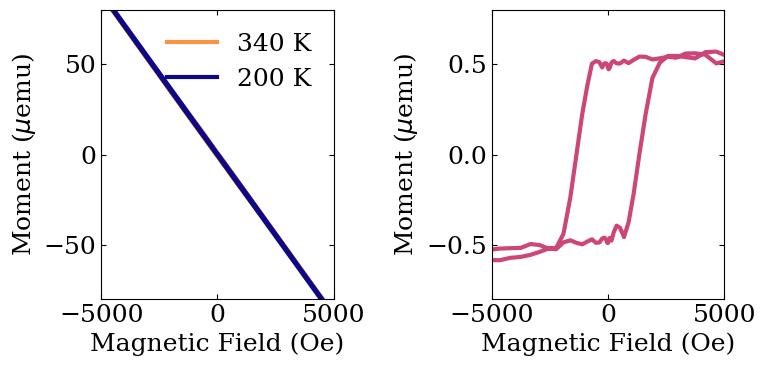

In [144]:
file1 = "MH-IP-200K.dat"
file2 = "MH-IP-340K.dat"
sample = '1560_mc4'
_, _, _ = plot_MH_difference('./SURF1560_Thick_4degMC_0degMount/', file2, file1, sample,v, 0, low_lim=-8000, upper_lim=8000, filter=True, filter_len=5, flatten=True)

Gradients  1.3596684858808347e-06 1.1378334330283959e-07


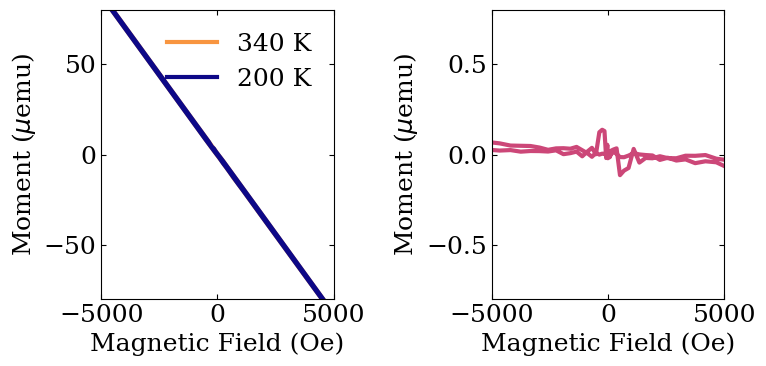

In [145]:
file1 = "MH-IP-200K.dat"
file2 = "MH-IP-340K.dat"
v=1
sample = 'Plain_substrate'
_, _, _ = plot_MH_difference('./Plain_Al2O3_substrate_with_silver/', file2, file1, sample,v, 0, low_lim=-8000, upper_lim=8000, filter=True, filter_len=5, flatten=True)

Gradients  -3.8830507445378244e-05 -3.071930328030567e-05


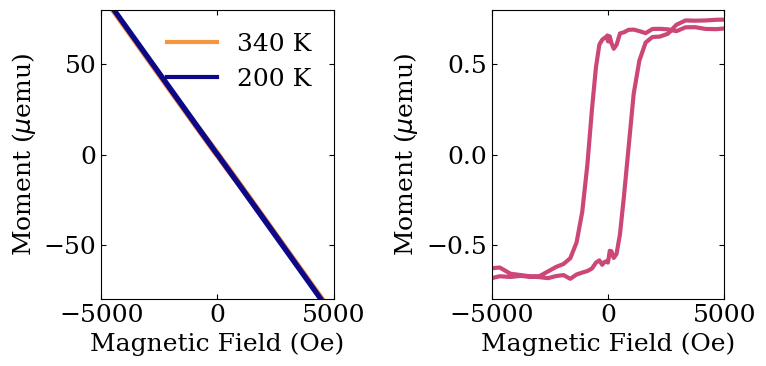

In [146]:
file1 = "MH-IP-200K.dat"
file2 = "MH-IP-340K.dat"
sample = '1560_mc0'
_, _, _ = plot_MH_difference('./SURF1560_Thick_0degMC_45CWdegMount/', file2, file1, sample,v, 0, low_lim=-8000, upper_lim=8000, filter=True, filter_len=5, flatten=True)